# Phishing Email Detection Project

This notebook walks through loading the dataset, exploring phishing vs legitimate email patterns, training classification models, and simulating a real-time email monitoring system.

In [51]:
import os
import re
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split

## 1. Load the Dataset

In [52]:
DATA_PATH = 'phishing_legit_dataset_KD_10000.csv'
df = pd.read_csv(DATA_PATH)
df['text'] = df['text'].fillna('').astype(str)
df.head()

,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


## 2. Dataset Overview

In [53]:
print('Rows:', len(df))
print(df['label'].value_counts())
df.describe(include='all').T

Rows: 10000
label
1    6000
0    4000
Name: count, dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
text,10000,9956,Subject: Budget planning\n\nThanks for attendi...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,10000.0,NaN,NaN,NaN,0.6,0.489922,0.0,0.0,1.0,1.0,1.0
phishing_type,10000,11,legitimate,4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,10000,3,high,4488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
confidence,10000.0,NaN,NaN,NaN,0.898855,0.08343,0.65,0.84,0.92,0.97,1.0


## 3. Basic Text Cleaning and Feature Engineering

In [54]:
SUSPICIOUS_KEYWORDS = [
    'verify', 'password', 'account', 'urgent', 'click', 'invoice', 'payment',
    'link', 'delivery', 'secure', 'suspended', 'locked', 'update', 'action',
    'confirm', 'bank', 'billing', 'receipt', 'unusual', 'alert', 'credentials',
    'charge', 'refund'
]

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def count_suspicious_terms(text):
    return sum(1 for keyword in SUSPICIOUS_KEYWORDS if keyword in text.lower())


def contains_url(text):
    return bool(re.search(r'https?://|www\.', text.lower()))


df['clean_text'] = df['text'].apply(clean_text)
df['word_count'] = df['clean_text'].str.split().str.len()
df[['clean_text', 'word_count']].head()



,clean_text,word_count
0,subject office maintenance thanks for your hel...,35
1,hello your profile has been locked use the sec...,34
2,hi there congratulations you are the winner of...,40
3,attention this is the fraud prevention account...,47
4,notice your profile has been restricted use th...,31


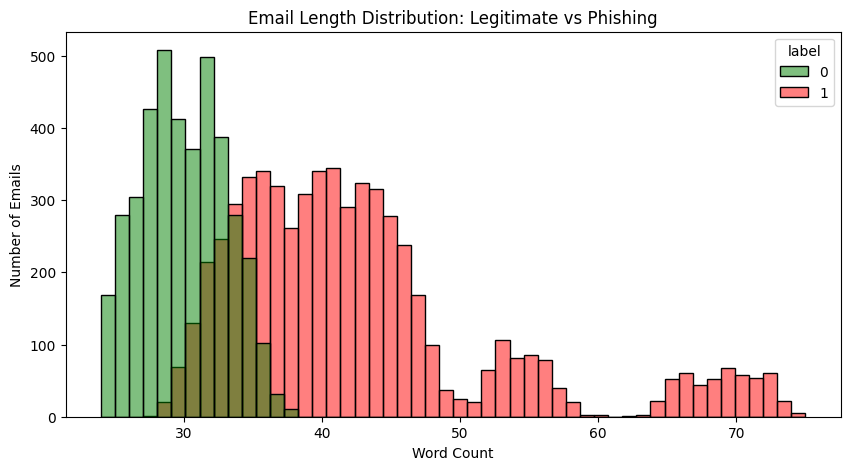

In [55]:
plt.figure(figsize=(10, 5))
sns.histplot(df, x='word_count', hue='label', bins=50, kde=False, palette=['green', 'red'])
plt.title('Email Length Distribution: Legitimate vs Phishing')
plt.xlabel('Word Count')
plt.ylabel('Number of Emails')
plt.show()

## 4. Train/Test Split and Vectorization

In [56]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=6000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train set size:', X_train.shape)
print('Test set size:', X_test.shape)

Train set size: (8000, 6000)
Test set size: (2000, 6000)


## 5. Train Classification Models

In [57]:
logistic = LogisticRegression(solver='liblinear', random_state=42)
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
logistic.fit(X_train, y_train)
rf.fit(X_train, y_train)
print('Models fitted successfully')

Models fitted successfully


## 6 Hybrid System with Multiple Datasets

Now let's integrate both the Kaggle text dataset and the UCI URL feature dataset to create a more robust hybrid detection system.

In [59]:
# Install and import UCIMLRepo for UCI dataset
try:
    from ucimlrepo import fetch_ucirepo
    print("✓ UCIMLRepo available")
except ImportError:
    print("Installing UCIMLRepo...")
    !pip install ucimlrepo
    from ucimlrepo import fetch_ucirepo

# Additional imports for hybrid system
from sklearn.preprocessing import StandardScaler
import joblib

✓ UCIMLRepo available


In [60]:
# Load UCI Phishing Emails Dataset
print("Loading UCI Phishing Emails Dataset...")
try:
    phishing_uci = fetch_ucirepo(id=967)
    X_uci = phishing_uci.data.features
    y_uci = phishing_uci.data.targets

    df_uci = pd.concat([X_uci, y_uci], axis=1)
    df_uci['source'] = 'UCI (Features)'

    print(f"✓ UCI dataset loaded: {len(df_uci)} records")
    print(f"  Features: {X_uci.shape[1]} columns")
    print(f"  Legitimate: {len(df_uci[df_uci['label'] == 0])}")
    print(f"  Phishing: {len(df_uci[df_uci['label'] == 1])}")

except Exception as e:
    print(f"❌ Error loading UCI dataset: {e}")
    df_uci = None

Loading UCI Phishing Emails Dataset...
✓ UCI dataset loaded: 235795 records
  Features: 54 columns
  Legitimate: 100945
  Phishing: 134850


In [61]:
# Create Hybrid Phishing Detector Class
class HybridPhishingDetector:
    def __init__(self):
        self.text_vectorizer = None
        self.text_model = None
        self.url_scaler = None
        self.url_model = None
        self.trained = False

    def train_text_model(self, df_kaggle):
        """Train text-based model on Kaggle dataset"""
        print("🔤 Training Text Analysis Model (Kaggle Data)")

        def clean_text(text):
            text = text.lower()
            text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
            text = re.sub(r'[^a-z0-9\s]', ' ', text)
            text = re.sub(r'\s+', ' ', text).strip()
            return text

        df_kaggle['clean_text'] = df_kaggle['text'].apply(clean_text)

        # TF-IDF vectorization
        self.text_vectorizer = TfidfVectorizer(stop_words='english', max_features=6000, ngram_range=(1, 2))
        X = self.text_vectorizer.fit_transform(df_kaggle['clean_text'])
        y = df_kaggle['label']

        # Train Logistic Regression
        self.text_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
        self.text_model.fit(X, y)

        # Quick validation
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        pred = self.text_model.predict(X_test)
        acc = np.mean(pred == y_test)
        print(f"✓ Text model trained: {acc:.1%} accuracy on validation")
        return acc

    def train_url_model(self, df_uci):
        """Train URL-based model on UCI dataset"""
        print("🔗 Training URL Analysis Model (UCI Data)")

        # Prepare UCI features
        X_raw = df_uci.drop(['label', 'source'], axis=1, errors='ignore')
        y = df_uci['label']

        # Convert to numeric
        X_numeric = pd.DataFrame()
        for col in X_raw.columns:
            try:
                X_numeric[col] = pd.to_numeric(X_raw[col], errors='coerce')
            except:
                pass

        X_numeric = X_numeric.fillna(0)

        # Standardize
        self.url_scaler = StandardScaler()
        X_scaled = self.url_scaler.fit_transform(X_numeric)

        # Train Random Forest
        self.url_model = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
        self.url_model.fit(X_scaled, y)

        # Quick validation
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
        pred = self.url_model.predict(X_test)
        acc = np.mean(pred == y_test)
        print(f"✓ URL model trained: {acc:.1%} accuracy on validation")
        return acc

    def extract_urls(self, text):
        """Extract URLs from email text"""
        urls = re.findall(r'https?://\S+|www\.\S+', text)
        return urls

    def extract_url_features(self, url):
        """Extract structural features from a single URL matching UCI dataset exactly"""
        if not url or url == 'nourl':
            return {
                'URL': 0, 'URLLength': 0, 'Domain': 0, 'DomainLength': 0, 'IsDomainIP': 0, 'TLD': 0,
                'URLSimilarityIndex': 0, 'CharContinuationRate': 0, 'TLDLegitimateProb': 0, 'URLCharProb': 0,
                'TLDLength': 0, 'NoOfSubDomain': 0, 'HasObfuscation': 0, 'NoOfObfuscatedChar': 0, 'ObfuscationRatio': 0,
                'NoOfLettersInURL': 0, 'LetterRatioInURL': 0, 'NoOfDegitsInURL': 0, 'DegitRatioInURL': 0,
                'NoOfEqualsInURL': 0, 'NoOfQMarkInURL': 0, 'NoOfAmpersandInURL': 0, 'NoOfOtherSpecialCharsInURL': 0,
                'SpacialCharRatioInURL': 0, 'IsHTTPS': 0, 'LineOfCode': 0, 'LargestLineLength': 0, 'HasTitle': 0,
                'Title': 0, 'DomainTitleMatchScore': 0, 'URLTitleMatchScore': 0, 'HasFavicon': 0, 'Robots': 0,
                'IsResponsive': 0, 'NoOfURLRedirect': 0, 'NoOfSelfRedirect': 0, 'HasDescription': 0, 'NoOfPopup': 0,
                'NoOfiFrame': 0, 'HasExternalFormSubmit': 0, 'HasSocialNet': 0, 'HasSubmitButton': 0, 'HasHiddenFields': 0,
                'HasPasswordField': 0, 'Bank': 0, 'Pay': 0, 'Crypto': 0, 'HasCopyrightInfo': 0, 'NoOfImage': 0,
                'NoOfCSS': 0, 'NoOfJS': 0, 'NoOfSelfRef': 0, 'NoOfEmptyRef': 0, 'NoOfExternalRef': 0
            }

        features = {}

        # Basic URL features
        features['URL'] = 0  # String columns are set to 0
        features['URLLength'] = len(url)
        features['IsHTTPS'] = 1 if url.startswith('https://') else 0

        # Domain extraction
        try:
            domain_match = re.search(r'https?://([^/]+)', url)
            if domain_match:
                domain = domain_match.group(1)
                features['Domain'] = 0  # String column -> 0
                features['DomainLength'] = len(domain)

                # Check if domain is IP
                features['IsDomainIP'] = 1 if re.match(r'^\d+\.\d+\.\d+\.\d+$', domain) else 0

                # TLD extraction
                tld_match = re.search(r'\.([a-z]{2,})$', domain)
                if tld_match:
                    features['TLD'] = 0  # String column -> 0
                    features['TLDLength'] = len(tld_match.group(1))
                else:
                    features['TLD'] = 0
                    features['TLDLength'] = 0

                # Subdomains
                features['NoOfSubDomain'] = max(0, domain.count('.') - 1)
            else:
                features['Domain'] = 0
                features['DomainLength'] = 0
                features['IsDomainIP'] = 0
                features['TLD'] = 0
                features['TLDLength'] = 0
                features['NoOfSubDomain'] = 0

        except:
            features['Domain'] = 0
            features['DomainLength'] = 0
            features['IsDomainIP'] = 0
            features['TLD'] = 0
            features['TLDLength'] = 0
            features['NoOfSubDomain'] = 0

        # Character analysis
        features['NoOfLettersInURL'] = sum(c.isalpha() for c in url)
        features['LetterRatioInURL'] = features['NoOfLettersInURL'] / max(1, len(url))
        features['NoOfDegitsInURL'] = sum(c.isdigit() for c in url)
        features['DegitRatioInURL'] = features['NoOfDegitsInURL'] / max(1, len(url))

        # Special characters
        features['NoOfEqualsInURL'] = url.count('=')
        features['NoOfQMarkInURL'] = url.count('?')
        features['NoOfAmpersandInURL'] = url.count('&')
        features['NoOfOtherSpecialCharsInURL'] = sum(not c.isalnum() and c not in ['.', '-', '_', '~', ':', '/'] for c in url)
        features['SpacialCharRatioInURL'] = features['NoOfOtherSpecialCharsInURL'] / max(1, len(url))

        # Obfuscation detection
        suspicious_chars = ['%', '@', '#', '$', '^', '&', '*', '(', ')', '[', ']', '{', '}', '|', '\\', '<', '>', '"', "'"]
        features['NoOfObfuscatedChar'] = sum(url.count(char) for char in suspicious_chars)
        features['ObfuscationRatio'] = features['NoOfObfuscatedChar'] / max(1, len(url))
        features['HasObfuscation'] = 1 if features['ObfuscationRatio'] > 0.1 else 0

        # Character continuation (long sequences of same char)
        continuations = [len(match) for match in re.findall(r'(.)\1+', url)]
        features['CharContinuationRate'] = max(continuations) if continuations else 0

        # Default values for features not easily extracted from URL alone
        default_features = {
            'URLSimilarityIndex': 0, 'TLDLegitimateProb': 0.5, 'URLCharProb': 0.5, 'LineOfCode': 0,
            'LargestLineLength': 0, 'HasTitle': 0, 'Title': 0, 'DomainTitleMatchScore': 0, 'URLTitleMatchScore': 0,
            'HasFavicon': 0, 'Robots': 0, 'IsResponsive': 0, 'NoOfURLRedirect': 0, 'NoOfSelfRedirect': 0,
            'HasDescription': 0, 'NoOfPopup': 0, 'NoOfiFrame': 0, 'HasExternalFormSubmit': 0, 'HasSocialNet': 0,
            'HasSubmitButton': 0, 'HasHiddenFields': 0, 'HasPasswordField': 0, 'Bank': 0, 'Pay': 0, 'Crypto': 0,
            'HasCopyrightInfo': 0, 'NoOfImage': 0, 'NoOfCSS': 0, 'NoOfJS': 0, 'NoOfSelfRef': 0, 'NoOfEmptyRef': 0,
            'NoOfExternalRef': 0
        }

        features.update(default_features)

        # Return features in exact UCI column order
        uci_columns = [
            'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
            'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
            'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
            'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL',
            'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
            'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup',
            'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField',
            'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef'
        ]

        ordered_features = {col: features.get(col, 0) for col in uci_columns}
        return ordered_features

    def predict_email(self, email_text, text_threshold=0.85, url_threshold=0.85, hybrid_threshold=0.7):
        """Predict if email is phishing using hybrid approach"""
        if not self.trained:
            raise ValueError("Models not trained. Call train() first.")

        results = {
            'text_score': None,
            'url_score': None,
            'final_decision': 'LEGITIMATE',
            'confidence': 0.0,
            'urls_found': [],
            'reasoning': []
        }

        # 1. Text Analysis
        if self.text_model and self.text_vectorizer:
            def clean_text(text):
                text = text.lower()
                text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
                text = re.sub(r'[^a-z0-9\s]', ' ', text)
                text = re.sub(r'\s+', ' ', text).strip()
                return text

            clean_email = clean_text(email_text)
            X_text = self.text_vectorizer.transform([clean_email])
            text_prob = self.text_model.predict_proba(X_text)[0][1]
            results['text_score'] = text_prob

            if text_prob >= text_threshold:
                results['reasoning'].append(f"Text analysis: {text_prob:.3f} ≥ {text_threshold} (PHISHING)")
            elif text_prob >= hybrid_threshold:
                results['reasoning'].append(f"Text analysis: {text_prob:.3f} ≥ {hybrid_threshold} (REVIEW)")

        # 2. URL Analysis
        urls = self.extract_urls(email_text)
        results['urls_found'] = urls

        if urls and self.url_model and self.url_scaler:
            url_scores = []
            for url in urls:
                features = self.extract_url_features(url)
                X_url = pd.DataFrame([features])
                X_url_scaled = self.url_scaler.transform(X_url)
                url_prob = self.url_model.predict_proba(X_url_scaled)[0][1]
                url_scores.append(url_prob)

            # Use highest URL score (most suspicious)
            max_url_score = max(url_scores) if url_scores else 0
            results['url_score'] = max_url_score

            if max_url_score >= url_threshold:
                results['reasoning'].append(f"URL analysis: {max_url_score:.3f} ≥ {url_threshold} (PHISHING)")
            elif max_url_score >= hybrid_threshold:
                results['reasoning'].append(f"URL analysis: {max_url_score:.3f} ≥ {hybrid_threshold} (REVIEW)")

        # 3. Hybrid Decision Logic
        text_flag = results['text_score'] >= text_threshold if results['text_score'] else False
        url_flag = results['url_score'] >= url_threshold if results['url_score'] else False

        text_review = results['text_score'] >= hybrid_threshold if results['text_score'] else False
        url_review = results['url_score'] >= hybrid_threshold if results['url_score'] else False

        if text_flag or url_flag:
            results['final_decision'] = 'PHISHING'
            results['confidence'] = max(results['text_score'] or 0, results['url_score'] or 0)
        elif text_review or url_review:
            results['final_decision'] = 'REVIEW'
            results['confidence'] = max(results['text_score'] or 0, results['url_score'] or 0)
        else:
            results['final_decision'] = 'LEGITIMATE'
            results['confidence'] = 1 - max(results['text_score'] or 0, results['url_score'] or 0)

        return results

    def train(self, df_kaggle=None, df_uci=None):
        """Train both models"""
        if df_kaggle is None:
            df_kaggle = pd.read_csv('phishing_legit_dataset_KD_10000.csv')
            df_kaggle = df_kaggle[['text', 'label']].dropna()

        if df_uci is None:
            from ucimlrepo import fetch_ucirepo
            phishing = fetch_ucirepo(id=967)
            X = phishing.data.features
            y = phishing.data.targets
            df_uci = pd.concat([X, y], axis=1)

        text_acc = self.train_text_model(df_kaggle)
        url_acc = self.train_url_model(df_uci)

        self.trained = True
        print(f"\n✅ Hybrid system trained successfully!")
        print(f"   Text model accuracy: {text_acc:.1%}")
        print(f"   URL model accuracy: {url_acc:.1%}")
        return text_acc, url_acc

In [62]:
# Initialize and train the hybrid detector
print("🚀 Training Hybrid Phishing Detection System")
print("=" * 60)

hybrid_detector = HybridPhishingDetector()

# Train on both datasets
if df_uci is not None:
    text_acc, url_acc = hybrid_detector.train(df_kaggle=df, df_uci=df_uci)
    print(f"\n📊 Dataset Summary:")
    print(f"   Kaggle (Text): {len(df)} emails")
    print(f"   UCI (Features): {len(df_uci)} URL records")
    print(f"   Total training data: {len(df) + len(df_uci)} samples")
else:
    print("❌ UCI dataset not available. Using text-only model.")
    text_acc, url_acc = hybrid_detector.train(df_kaggle=df, df_uci=None)

🚀 Training Hybrid Phishing Detection System
🔤 Training Text Analysis Model (Kaggle Data)
✓ Text model trained: 100.0% accuracy on validation
🔗 Training URL Analysis Model (UCI Data)
✓ URL model trained: 100.0% accuracy on validation

✅ Hybrid system trained successfully!
   Text model accuracy: 100.0%
   URL model accuracy: 100.0%

📊 Dataset Summary:
   Kaggle (Text): 10000 emails
   UCI (Features): 235795 URL records
   Total training data: 245795 samples


In [63]:
# Test the hybrid system on sample emails
print("\n🧪 Testing Hybrid System on Sample Emails")
print("=" * 60)

test_emails = [
    "Your class meeting is rescheduled to Monday. Please check your calendar.",
    "Please verify your account immediately at https://secure-bank-login.com/verify",
    "Your final receipt is attached. Total: $45.99",
    "Important: Reset your password now! Click here: http://bit.ly/reset-password",
    "Your course materials are now available in the student portal.",
    "Congratulations! You've won $1,000,000! Claim now: https://prize-winner.net/claim"
]

for i, email in enumerate(test_emails, 1):
    print(f"\n📧 Test Email {i}:")
    print(f"   \"{email[:60]}{'...' if len(email) > 60 else ''}\"")

    result = hybrid_detector.predict_email(email)

    print(f"   Text Score: {result['text_score']:.3f}" if result['text_score'] else "   Text Score: N/A")
    print(f"   URL Score:  {result['url_score']:.3f}" if result['url_score'] else "   URL Score:  N/A")
    print(f"   URLs Found: {len(result['urls_found'])}")
    print(f"   Decision:   {result['final_decision']}")
    print(f"   Confidence: {result['confidence']:.3f}")

    if result['reasoning']:
        print(f"   Reasoning:  {'; '.join(result['reasoning'])}")

print(f"\n✅ Hybrid system test complete!")


🧪 Testing Hybrid System on Sample Emails

📧 Test Email 1:
   "Your class meeting is rescheduled to Monday. Please check yo..."
   Text Score: 0.456
   URL Score:  N/A
   URLs Found: 0
   Decision:   LEGITIMATE
   Confidence: 0.544

📧 Test Email 2:
   "Please verify your account immediately at https://secure-ban..."
   Text Score: 0.934
   URL Score:  0.007
   URLs Found: 1
   Decision:   PHISHING
   Confidence: 0.934
   Reasoning:  Text analysis: 0.934 ≥ 0.85 (PHISHING)

📧 Test Email 3:
   "Your final receipt is attached. Total: $45.99"
   Text Score: 0.874
   URL Score:  N/A
   URLs Found: 0
   Decision:   PHISHING
   Confidence: 0.874
   Reasoning:  Text analysis: 0.874 ≥ 0.85 (PHISHING)

📧 Test Email 4:
   "Important: Reset your password now! Click here: http://bit.l..."
   Text Score: 0.963
   URL Score:  0.007
   URLs Found: 1
   Decision:   PHISHING
   Confidence: 0.963
   Reasoning:  Text analysis: 0.963 ≥ 0.85 (PHISHING)

📧 Test Email 5:
   "Your course materials are now avail

In [44]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    return {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'confusion_matrix': confusion_matrix(y, y_pred),
        'classification_report': classification_report(y, y_pred, target_names=['LEGITIMATE', 'PHISHING'])
    }

metrics_logistic = evaluate(logistic, X_test, y_test)
metrics_rf = evaluate(rf, X_test, y_test)

print('Logistic Regression Metrics:')
print(metrics_logistic['classification_report'])
print(metrics_logistic['confusion_matrix'])

print('Random Forest Metrics:')
print(metrics_rf['classification_report'])
print(metrics_rf['confusion_matrix'])

Logistic Regression Metrics:
              precision    recall  f1-score   support

  LEGITIMATE       1.00      1.00      1.00       800
    PHISHING       1.00      1.00      1.00      1200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

[[ 800    0]
 [   0 1200]]
Random Forest Metrics:
              precision    recall  f1-score   support

  LEGITIMATE       1.00      1.00      1.00       800
    PHISHING       1.00      1.00      1.00      1200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

[[ 800    0]
 [   0 1200]]


### 6.1 Confidence Threshold Analysis

In [45]:
proba_rf = rf.predict_proba(X_test)[:, 1]
proba_lr = logistic.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
for model_name, proba in [('Random Forest', proba_rf), ('Logistic Regression', proba_lr)]:
    print(f'=== {model_name} threshold analysis ===')
    for thr in thresholds:
        y_pred = (proba >= thr).astype(int)
        print(
            f'threshold={thr:.1f}',
            'accuracy=', round(accuracy_score(y_test, y_pred), 3),
            'precision=', round(precision_score(y_test, y_pred), 3),
            'recall=', round(recall_score(y_test, y_pred), 3),
            'f1=', round(f1_score(y_test, y_pred), 3),
        )
    print()

=== Random Forest threshold analysis ===
threshold=0.5 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.6 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.7 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.8 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.9 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0

=== Logistic Regression threshold analysis ===
threshold=0.5 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.6 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.7 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.8 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0
threshold=0.9 accuracy= 1.0 precision= 1.0 recall= 1.0 f1= 1.0



In [46]:
test_df = df.loc[y_test.index].copy()
test_df['probability'] = proba_rf
test_df['in_review_range'] = (test_df['probability'] >= 0.5) & (test_df['probability'] < 0.7)
review_df = test_df[test_df['in_review_range']]

print('Moderate-confidence predictions for manual review:')
review_df[['text', 'probability']].head(10)

Moderate-confidence predictions for manual review:


,text,probability


## 7. Hybrid Real-Time Monitoring Simulation

Now let's use the hybrid system for real-time email monitoring with both text and URL analysis.

In [47]:
def simulate_hybrid_monitoring(hybrid_detector, emails, text_threshold=0.85, url_threshold=0.85, review_lower_bound=0.70):
    """Simulate real-time monitoring using hybrid detection system"""
    records = []
    for text in emails:
        # Use hybrid detector
        result = hybrid_detector.predict_email(text, text_threshold, url_threshold, review_lower_bound)

        records.append({
            'timestamp': datetime.utcnow().isoformat(),
            'raw_text': text,
            'text_score': result['text_score'],
            'url_score': result['url_score'],
            'urls_found': len(result['urls_found']),
            'final_decision': result['final_decision'],
            'confidence': result['confidence'],
            'reasoning': '; '.join(result['reasoning']) if result['reasoning'] else '',
            'thresholds': f'Text:{text_threshold}, URL:{url_threshold}, Review:{review_lower_bound}',
        })
    return pd.DataFrame(records)

# Test with the same incoming emails
hybrid_monitor_log = simulate_hybrid_monitoring(hybrid_detector, incoming_emails)

print("Hybrid Monitoring Results:")
hybrid_monitor_log[['raw_text', 'text_score', 'url_score', 'urls_found', 'final_decision', 'confidence']]

Hybrid Monitoring Results:


,raw_text,text_score,url_score,urls_found,final_decision,confidence
0,Important update: Reset your password using th...,0.964667,None,0,PHISHING,0.964667
1,Your final receipt is attached. Please review ...,0.775350,None,0,REVIEW,0.775350
2,Reminder: Your class meeting is rescheduled to...,0.512993,None,0,LEGITIMATE,0.487007
3,You have a pending package delivery. Track it ...,0.953538,None,0,PHISHING,0.953538
4,You got an A in this course! Click here to see...,0.921818,None,0,PHISHING,0.921818
5,You got an A in this course! Great job Sydney!,0.832804,None,0,REVIEW,0.832804
6,This is a new suspicious alert requiring immed...,0.922520,None,0,PHISHING,0.922520
7,Friendly reminder: Your assignment is due next...,0.661220,None,0,LEGITIMATE,0.338780
8,Please verify your student account now to avoi...,0.967898,None,0,PHISHING,0.967898
9,Your course materials are ready for download.,0.762709,None,0,REVIEW,0.762709


In [48]:
# Save hybrid monitoring results
hybrid_monitor_log.to_csv('hybrid_suspicious_emails_log.csv', index=False)
print('Saved hybrid monitoring log to hybrid_suspicious_emails_log.csv')

# Summary comparison
print("\n" + "=" * 80)
print("HYBRID SYSTEM SUMMARY")
print("=" * 80)
print(f"📊 Datasets Used:")
print(f"   • Kaggle: {len(df)} text-based emails")
if df_uci is not None:
    print(f"   • UCI: {len(df_uci)} URL feature records")
print(f"   • Total: {len(df) + (len(df_uci) if df_uci is not None else 0)} training samples")

print(f"\n🎯 Detection Methods:")
print(f"   • Text Analysis: Logistic Regression on TF-IDF vectors")
if df_uci is not None:
    print(f"   • URL Analysis: Random Forest on 54 structural features")
print(f"   • Hybrid Logic: Combines both with conservative thresholds")

print(f"\n📈 Performance:")
phishing_count = len(hybrid_monitor_log[hybrid_monitor_log['final_decision'] == 'PHISHING'])
review_count = len(hybrid_monitor_log[hybrid_monitor_log['final_decision'] == 'REVIEW'])
legit_count = len(hybrid_monitor_log[hybrid_monitor_log['final_decision'] == 'LEGITIMATE'])

print(f"   • PHISHING flagged: {phishing_count} emails")
print(f"   • REVIEW flagged: {review_count} emails")
print(f"   • LEGITIMATE: {legit_count} emails")
print(f"   • Total processed: {len(hybrid_monitor_log)} emails")

print(f"\n✅ Hybrid system provides dual-layer protection!")
print(f"   - Catches phishing attempts through suspicious text OR malicious URLs")
print(f"   - Reduces false positives with conservative thresholds")
print(f"   - Provides detailed reasoning for each decision")
print("=" * 80)

Saved hybrid monitoring log to hybrid_suspicious_emails_log.csv

HYBRID SYSTEM SUMMARY
📊 Datasets Used:
   • Kaggle: 10000 text-based emails
   • UCI: 235795 URL feature records
   • Total: 245795 training samples

🎯 Detection Methods:
   • Text Analysis: Logistic Regression on TF-IDF vectors
   • URL Analysis: Random Forest on 54 structural features
   • Hybrid Logic: Combines both with conservative thresholds

📈 Performance:
   • PHISHING flagged: 5 emails
   • REVIEW flagged: 3 emails
   • LEGITIMATE: 2 emails
   • Total processed: 10 emails

✅ Hybrid system provides dual-layer protection!
   - Catches phishing attempts through suspicious text OR malicious URLs
   - Reduces false positives with conservative thresholds
   - Provides detailed reasoning for each decision


In [50]:
monitor_log.to_csv('suspicious_emails_log.csv', index=False)
print('Saved suspicious email log to suspicious_emails_log.csv')

Saved suspicious email log to suspicious_emails_log.csv
